# Stock Market Analyzer

This project downloads live stock market data using the Yahoo Finance API and visualizes historical stock performance.

In [12]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## Download Live Stock Data

In [13]:
ticker = "NVDA"

history = yf.download(
    ticker,
    period="1y",
    progress=False
)

history.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-06-30,157.779846,158.448953,155.752548,158.189289,194580300
2025-07-01,153.096100,156.990906,151.288510,156.082113,213143600
2025-07-02,157.040848,157.390388,152.766542,152.776523,171224100
2025-07-03,159.128052,160.765870,157.560148,158.159341,143716100
2025-07-07,158.029510,159.098079,157.130699,157.989555,140139000


In [14]:
# Flatten the column names if they are a MultiIndex
if isinstance(history.columns, pd.MultiIndex):
    history.columns = history.columns.get_level_values(0)

history.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-06-30,157.779846,158.448953,155.752548,158.189289,194580300
2025-07-01,153.096100,156.990906,151.288510,156.082113,213143600
2025-07-02,157.040848,157.390388,152.766542,152.776523,171224100
2025-07-03,159.128052,160.765870,157.560148,158.159341,143716100
2025-07-07,158.029510,159.098079,157.130699,157.989555,140139000


In [15]:
print(history.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


## Summary Statistics

To better understand the stock's historical performance, we calculate several descriptive statistics from the downloaded data.

These metrics provide a quick overview of price movement and trading activity over the selected time period.

In [16]:
current_price = history["Close"].iloc[-1]
highest_price = history["High"].max()
lowest_price = history["Low"].min()
average_close = history["Close"].mean()
average_volume = history["Volume"].mean()

total_return = (
    (history["Close"].iloc[-1] - history["Close"].iloc[0])
    / history["Close"].iloc[0]
) * 100

summary = pd.DataFrame({
    "Metric": [
        "Current Price",
        "Highest Price",
        "Lowest Price",
        "Average Close",
        "Average Volume",
        "Trading Days",
        "Total Return (%)"
    ],
    "Value": [
        f"${current_price:.2f}",
        f"${highest_price:.2f}",
        f"${lowest_price:.2f}",
        f"${average_close:.2f}",
        f"{average_volume:,.0f}",
        len(history),
        f"{total_return:.2f}%"
    ]
})

summary

,Metric,Value
0,Current Price,$193.88
1,Highest Price,$236.26
2,Lowest Price,$151.29
3,Average Close,$186.89
4,Average Volume,"174,624,559"
5,Trading Days,251
6,Total Return (%),22.88%


## Historical Price Visualization

The following visualization shows the historical closing price for the selected stock over the specified analysis period.

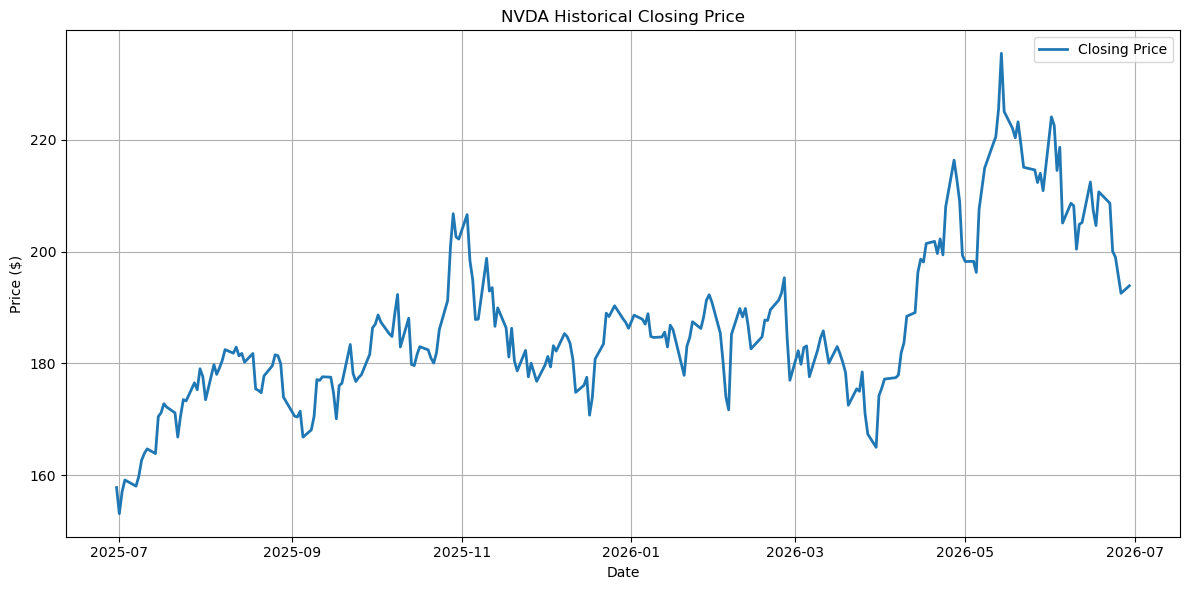

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    history.index,
    history["Close"],
    linewidth=2,
    label="Closing Price"
)

plt.title(f"{ticker} Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
history["Close"].describe()

count    251.000000
mean     186.893354
std       14.598282
min      153.096100
25%      177.618408
50%      183.466232
75%      192.764519
max      235.465576
Name: Close, dtype: float64

## Conclusion

This notebook demonstrates a simple financial analysis workflow using Python.

Using live market data from Yahoo Finance, we retrieved historical stock prices, calculated descriptive statistics, and visualized price performance. This workflow provides a foundation for more advanced financial analysis, including moving averages, volatility analysis, and stock comparisons.